In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

dataset_path = "/content/drive/MyDrive/Colab Notebooks/dataset_red panda & raccoon"

if dataset_path == "FIX_ME":
    print("[BELUM LENGKAP] Gantikan dataset_path dengan lokasi folder sebenar.")
else:
    train_dir = dataset_path + "/train"
    test_dir = dataset_path + "/test"
    print("Train folder exists:", os.path.exists(train_dir))
    print("Test folder exists :", os.path.exists(test_dir))
    if os.path.exists(train_dir): print("Train classes:", os.listdir(train_dir))
    if os.path.exists(test_dir): print("Test classes :", os.listdir(test_dir))

Train folder exists: True
Test folder exists : True
Train classes: ['red panda', 'raccoon']
Test classes : ['raccoon', 'red panda']


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Peranti digunakan:", device)

Peranti digunakan: cuda


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])
print("[SEDIA] Image transforms telah ditetapkan.")

[SEDIA] Image transforms telah ditetapkan.


In [5]:
if "train_dir" not in globals() or "test_dir" not in globals():
    print("[BELUM SEDIA] Lengkapkan dataset_path dahulu.")
    train_dataset = test_dataset = None
else:
    train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
    test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)
    print("Class names     :", train_dataset.classes)
    print("Class mapping   :", train_dataset.class_to_idx)
    print("Training images :", len(train_dataset))
    print("Testing images  :", len(test_dataset))

Class names     : ['raccoon', 'red panda']
Class mapping   : {'raccoon': 0, 'red panda': 1}
Training images : 60
Testing images  : 60


Batch image shape: torch.Size([60, 3, 64, 64])
Batch label shape: torch.Size([60])


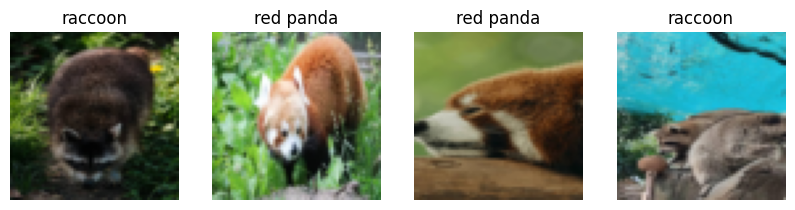

In [6]:
if train_dataset is None or test_dataset is None:
    print("[BELUM SEDIA] Load dataset dahulu.")
    train_loader = test_loader = None
else:
    train_loader = DataLoader(train_dataset, batch_size=60, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=60, shuffle=False)
    images, labels = next(iter(train_loader))
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    plt.figure(figsize=(10,4))
    for i in range(min(4, len(images))):
        image = images[i].permute(1,2,0)
        class_name = train_dataset.classes[labels[i].item()]
        plt.subplot(1,4,i+1)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")
    plt.show()

In [7]:
INPUT_CHANNELS = 3
OUTPUT_CLASSES = 2

class RaccoonRedpanda(nn.Module):
    def __init__(self):
        super().__init__()
        if INPUT_CHANNELS is None or OUTPUT_CLASSES is None:
            raise ValueError("Lengkapkan INPUT_CHANNELS dan OUTPUT_CLASSES dahulu.")
        self.features = nn.Sequential(
            nn.Conv2d(INPUT_CHANNELS, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 8 * 8, 128), nn.ReLU(), nn.Linear(128, OUTPUT_CLASSES)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

try:
    model = RaccoonRedpanda().to(device)
    print(model)
except Exception as e:
    model = None
    print("[BELUM LENGKAP]", e)

RaccoonRedpanda(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [8]:
if model is None:
    print("[BELUM SEDIA] Lengkapkan model dahulu.")
    criterion = optimizer = epochs = None
else:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    epochs = 3
    if criterion is None or optimizer is None or epochs is None:
        print("[BELUM LENGKAP] Lengkapkan criterion, optimizer dan epochs.")

In [9]:
if model is None or train_loader is None or criterion is None or optimizer is None or epochs is None:
    print("[BELUM SEDIA] Lengkapkan dataset, model dan training setup dahulu.")
    training_complete = False
    train_losses = []
    train_accuracies = []
else:
    train_losses = []
    train_accuracies = []
    for epoch in range(epochs):
        model.train(); running_loss = 0.0; correct = 0; total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item(); total += labels.size(0)
        accuracy = correct / total if total else 0
        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(accuracy)
        print(f"Epoch {epoch+1}/{epochs}: Loss={running_loss / len(train_loader):.4f}, Accuracy={accuracy:.4f}")
    training_complete = True

Epoch 1/3: Loss=0.6957, Accuracy=0.5000
Epoch 2/3: Loss=0.6919, Accuracy=0.6167
Epoch 3/3: Loss=0.6901, Accuracy=0.5000


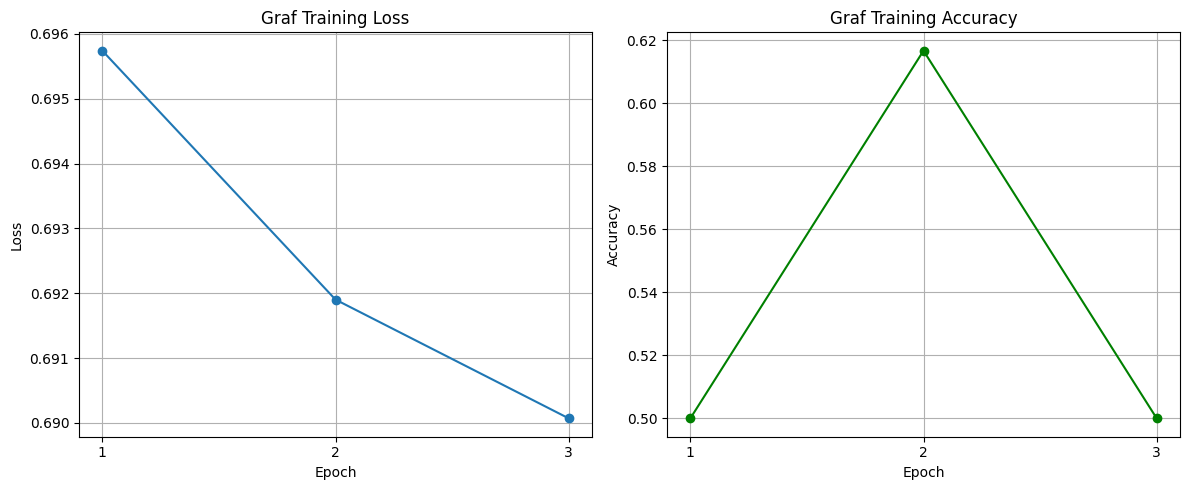

In [10]:
import matplotlib.pyplot as plt

if not globals().get("training_complete", False):
    print("[BELUM SEDIA] Train model dahulu.")
else:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), train_losses, marker='o')
    plt.title("Graf Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(range(1, epochs + 1))
    plt.grid(True)


    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), train_accuracies, marker='o', color='green')
    plt.title("Graf Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.xticks(range(1, epochs + 1))
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Test Accuracy: 0.5333


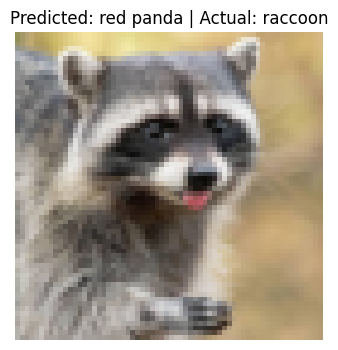

Predicted: red panda
Actual   : raccoon


In [11]:
if not globals().get("training_complete", False):
    print("[BELUM SEDIA] Train model dahulu.")
else:
    model.eval(); correct = 0; total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item(); total += labels.size(0)
    test_accuracy = correct / total if total else 0
    print("Test Accuracy:", f"{test_accuracy:.4f}")
    image, actual_label = test_dataset[5]
    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        predicted_label = torch.argmax(output, dim=1).item()
    predicted_class = test_dataset.classes[predicted_label]
    actual_class = test_dataset.classes[actual_label]
    plt.figure(figsize=(4,4))
    plt.imshow(image.permute(1,2,0))
    plt.title(f"Predicted: {predicted_class} | Actual: {actual_class}")
    plt.axis("off")
    plt.show()
    print("Predicted:", predicted_class)
    print("Actual   :", actual_class)

In [21]:
if model is None:
    print("[BELUM SEDIA] Lengkapkan model dahulu.")
    criterion = optimizer = epochs = None
else:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    epochs = 5
    if criterion is None or optimizer is None or epochs is None:
        print("[BELUM LENGKAP] Lengkapkan criterion, optimizer dan epochs.")

In [22]:
if model is None or train_loader is None or criterion is None or optimizer is None or epochs is None:
    print("[BELUM SEDIA] Lengkapkan dataset, model dan training setup dahulu.")
    training_complete = False
    train_losses = []
    train_accuracies = []
else:
    train_losses = []
    train_accuracies = []
    for epoch in range(epochs):
        model.train(); running_loss = 0.0; correct = 0; total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item(); total += labels.size(0)
        accuracy = correct / total if total else 0
        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(accuracy)
        print(f"Epoch {epoch+1}/{epochs}: Loss={running_loss / len(train_loader):.4f}, Accuracy={accuracy:.4f}")
    training_complete = True

Epoch 1/5: Loss=0.6886, Accuracy=0.5667
Epoch 2/5: Loss=0.6869, Accuracy=0.5833
Epoch 3/5: Loss=0.6857, Accuracy=0.5833
Epoch 4/5: Loss=0.6845, Accuracy=0.6000
Epoch 5/5: Loss=0.6827, Accuracy=0.6167


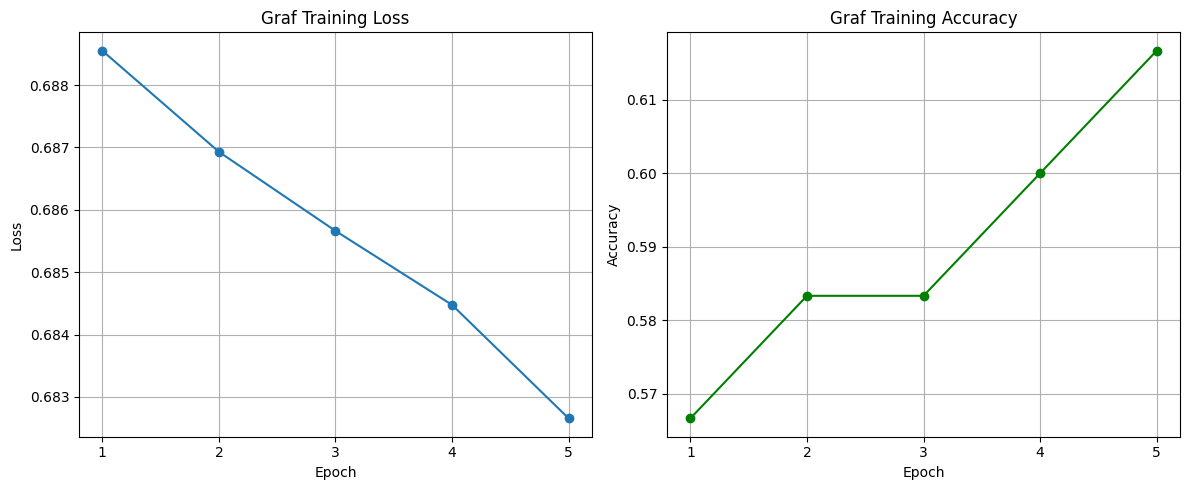

In [25]:
import matplotlib.pyplot as plt

if not globals().get("training_complete", False):
    print("[BELUM SEDIA] Train model dahulu.")
else:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), train_losses, marker='o')
    plt.title("Graf Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(range(1, epochs + 1))
    plt.grid(True)


    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), train_accuracies, marker='o', color='green')
    plt.title("Graf Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.xticks(range(1, epochs + 1))
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Test Accuracy: 0.5167


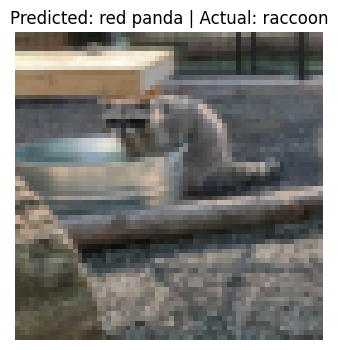

Predicted: red panda
Actual   : raccoon


In [26]:
if not globals().get("training_complete", False):
    print("[BELUM SEDIA] Train model dahulu.")
else:
    model.eval(); correct = 0; total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item(); total += labels.size(0)
    test_accuracy = correct / total if total else 0
    print("Test Accuracy:", f"{test_accuracy:.4f}")
    image, actual_label = test_dataset[7]
    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        predicted_label = torch.argmax(output, dim=1).item()
    predicted_class = test_dataset.classes[predicted_label]
    actual_class = test_dataset.classes[actual_label]
    plt.figure(figsize=(4,4))
    plt.imshow(image.permute(1,2,0))
    plt.title(f"Predicted: {predicted_class} | Actual: {actual_class}")
    plt.axis("off")
    plt.show()
    print("Predicted:", predicted_class)
    print("Actual   :", actual_class)

In [31]:
if model is None:
    print("[BELUM SEDIA] Lengkapkan model dahulu.")
    criterion = optimizer = epochs = None
else:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    epochs = 10
    if criterion is None or optimizer is None or epochs is None:
        print("[BELUM LENGKAP] Lengkapkan criterion, optimizer dan epochs.")

In [32]:
if model is None or train_loader is None or criterion is None or optimizer is None or epochs is None:
    print("[BELUM SEDIA] Lengkapkan dataset, model dan training setup dahulu.")
    training_complete = False
    train_losses = []
    train_accuracies = []
else:
    train_losses = []
    train_accuracies = []
    for epoch in range(epochs):
        model.train(); running_loss = 0.0; correct = 0; total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item(); total += labels.size(0)
        accuracy = correct / total if total else 0
        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(accuracy)
        print(f"Epoch {epoch+1}/{epochs}: Loss={running_loss / len(train_loader):.4f}, Accuracy={accuracy:.4f}")
    training_complete = True

Epoch 1/10: Loss=0.6288, Accuracy=0.7167
Epoch 2/10: Loss=0.6210, Accuracy=0.7000
Epoch 3/10: Loss=0.6103, Accuracy=0.7333
Epoch 4/10: Loss=0.6005, Accuracy=0.7500
Epoch 5/10: Loss=0.5854, Accuracy=0.7500
Epoch 6/10: Loss=0.5804, Accuracy=0.7833
Epoch 7/10: Loss=0.5522, Accuracy=0.8000
Epoch 8/10: Loss=0.5440, Accuracy=0.7667
Epoch 9/10: Loss=0.5297, Accuracy=0.7833
Epoch 10/10: Loss=0.5103, Accuracy=0.7833


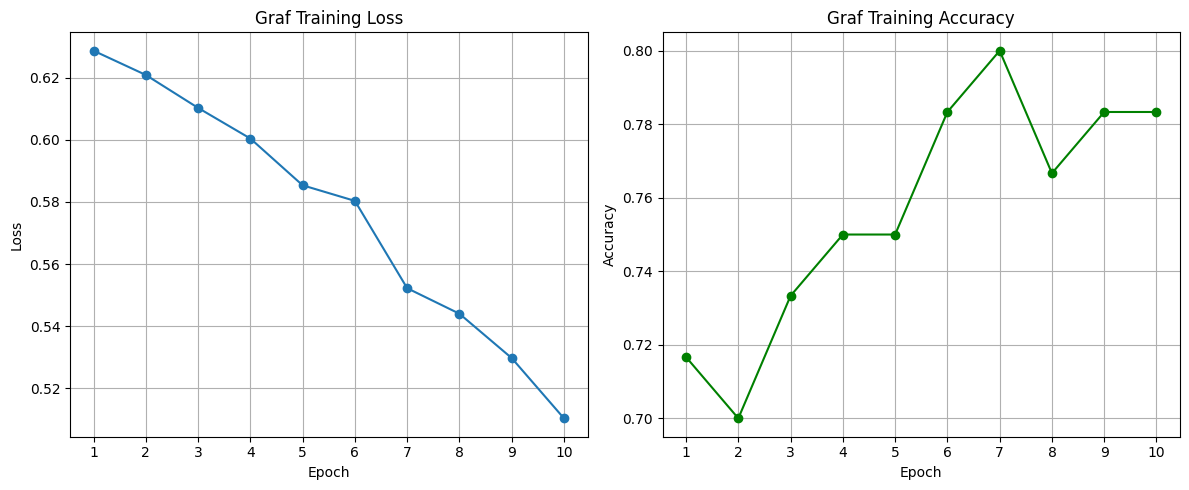

In [33]:
import matplotlib.pyplot as plt

if not globals().get("training_complete", False):
    print("[BELUM SEDIA] Train model dahulu.")
else:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), train_losses, marker='o')
    plt.title("Graf Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(range(1, epochs + 1))
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), train_accuracies, marker='o', color='green')
    plt.title("Graf Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.xticks(range(1, epochs + 1))
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Test Accuracy: 0.7667


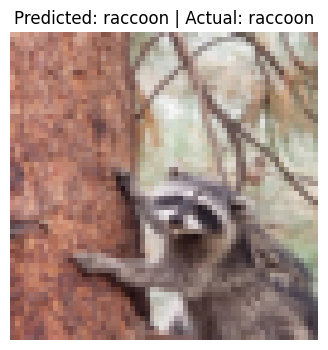

Predicted: raccoon
Actual   : raccoon


In [35]:
if not globals().get("training_complete", False):
    print("[BELUM SEDIA] Train model dahulu.")
else:
    model.eval(); correct = 0; total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item(); total += labels.size(0)
    test_accuracy = correct / total if total else 0
    print("Test Accuracy:", f"{test_accuracy:.4f}")
    image, actual_label = test_dataset[20]
    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        predicted_label = torch.argmax(output, dim=1).item()
    predicted_class = test_dataset.classes[predicted_label]
    actual_class = test_dataset.classes[actual_label]
    plt.figure(figsize=(4,4))
    plt.imshow(image.permute(1,2,0))
    plt.title(f"Predicted: {predicted_class} | Actual: {actual_class}")
    plt.axis("off")
    plt.show()
    print("Predicted:", predicted_class)
    print("Actual   :", actual_class)

In [36]:
import os
import torch

save_dir = "/content/drive/MyDrive/Colab Notebooks"
save_path = os.path.join(save_dir, "raccoon_redpanda_model.pth")

if globals().get("training_complete", False):
    os.makedirs(save_dir, exist_ok=True)

    torch.save(model.state_dict(), save_path)

    print("Model disimpan sebagai:", save_path)
else:
    print("Model belum disimpan kerana training_complete masih False.")

Model disimpan sebagai: /content/drive/MyDrive/Colab Notebooks/raccoon_redpanda_model.pth
